<a href="https://colab.research.google.com/github/nhatminhvu146-cmyk/Personality_segmentation_project/blob/main/Personality_Segmentation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Great Learning-MIT course /first_project_1st/Customer_Personality_Segmentation.csv", sep="\t")

## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

##### **Observations:**

In [ ]:
#Finding the data types of all columns
data.dtypes


,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
# Check the statistical summary of the data
data.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
#Finding the the average household income
print(f' the average household income is {data['Income'].mean():.3f} $')

 the average household income is 52247.251 $


##### **Observations: We can sse that the average household income of the data is approximate 52247.251 $**

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
#Checking for any missing Values in the data
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
#Treating the missing values with approximate method
# Numerical missing data -> mean of the columns
num_cols_mis = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols_mis] = data[num_cols_mis].fillna(data[num_cols_mis].mean())
# Categorical missing data -> mode
cat_cols_mis = data.select_dtypes(include='object').columns
data[cat_cols_mis] = data[cat_cols_mis].fillna(data[cat_cols_mis].mode().iloc[0])
#Checking any missing Values after treating
print('Missing Values after treating')
data.isnull().sum()

Missing Values after treating


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


##### **Observations: We can sse that there are 24 missing Values in the dataset. However, By replacing missing numerical data with the mean of its columns and replacing categorical data with mode of its columns. we can treat the missing values apporiately**

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
# Finding the duplicates in the data
if data.duplicated().sum() > 0:
    print("There are duplicates in the data")
else:
    print("There are no duplicates in the data")


There are no duplicates in the data


##### Observations: There are no duplicate in the data right now

## **Data Preprocessing**

In [ ]:
# Adding 'Age' column based on 'Year_Birth' column for later analysis
from datetime import datetime

# Getting the current year
current_year = datetime.now().year

# Calculating the age of the customer
data['Age'] = current_year - data['Year_Birth']

In [ ]:
# Dropping columns that are irrrelevant to later analysis
columns_to_drop = ['Dt_Customer','Year_Birth','ID','AcceptedCmp1', 'Z_CostContact', 'Z_Revenue', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Education', 'Marital_Status']
data.drop(columns=columns_to_drop, inplace=True)

In [ ]:
#Adding 'Total_Spending' to have a better view of total spending in later analysis
data['Total_Spending'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

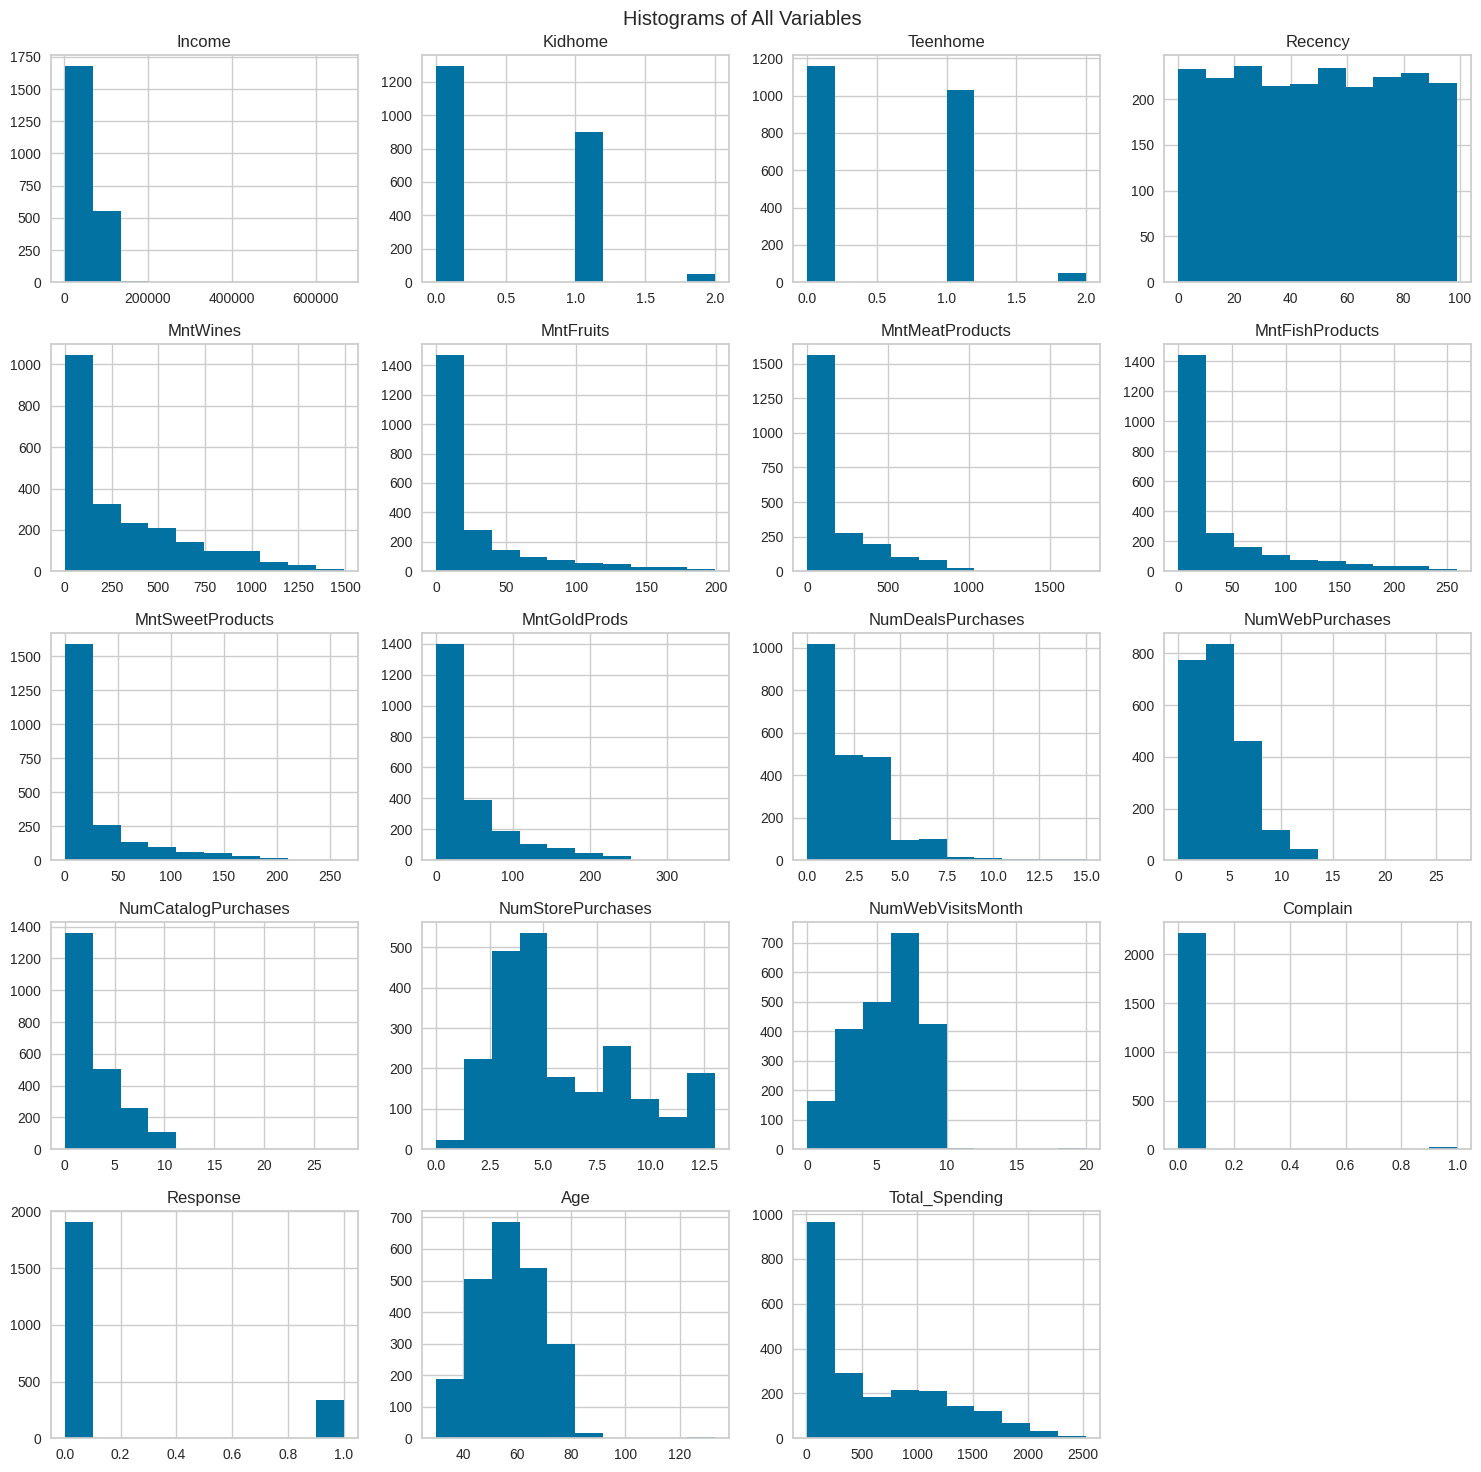

<Figure size 800x550 with 0 Axes>

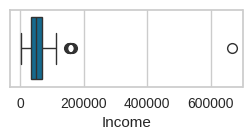

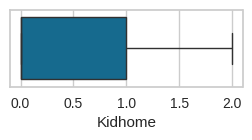

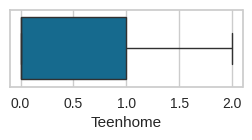

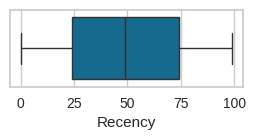

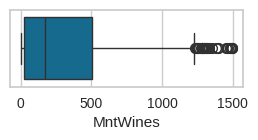

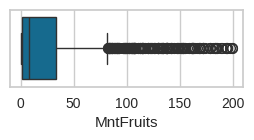

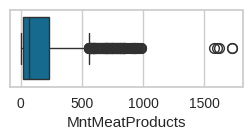

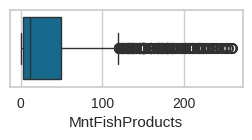

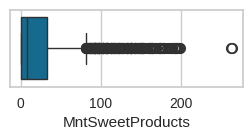

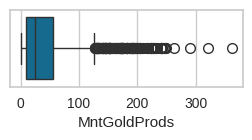

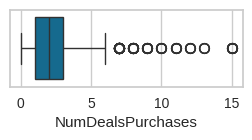

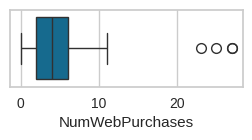

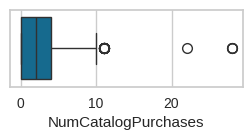

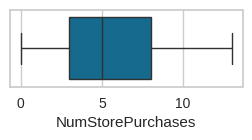

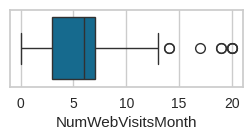

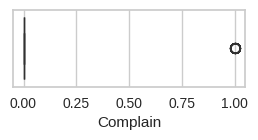

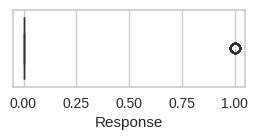

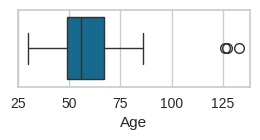

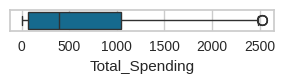

In [ ]:
# Plotting the Histograms for each variables
data.hist(figsize=(15, 15))
plt.suptitle("Histograms of All Variables")
plt.tight_layout()
plt.show()
# Plotting the Boxplots for each variables
plt.suptitle("Boxplots of All Variables")
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(3, 1))
    sns.boxplot(x=data[col])
plt.tight_layout()
plt.show()


##### **Observations:**

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

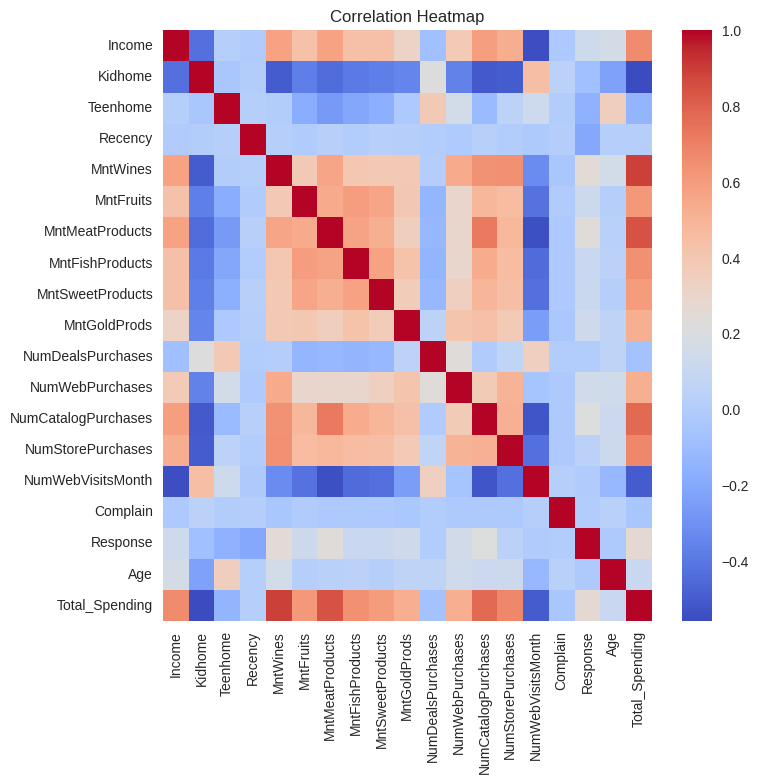

In [ ]:
# Using the heatmap to check for the correlation between numeric variables
plt.figure(figsize=(8, 8))
# Selecting only numerical columns for correlation calculation
sns.heatmap(data.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

##### **Observations: Based on the heatmap, we can see that there is a strong correlation between the Income and the spending of customers. Moreover, the Relationship between the spending based on the online purchases and the In-store purchases also a stand-out component**

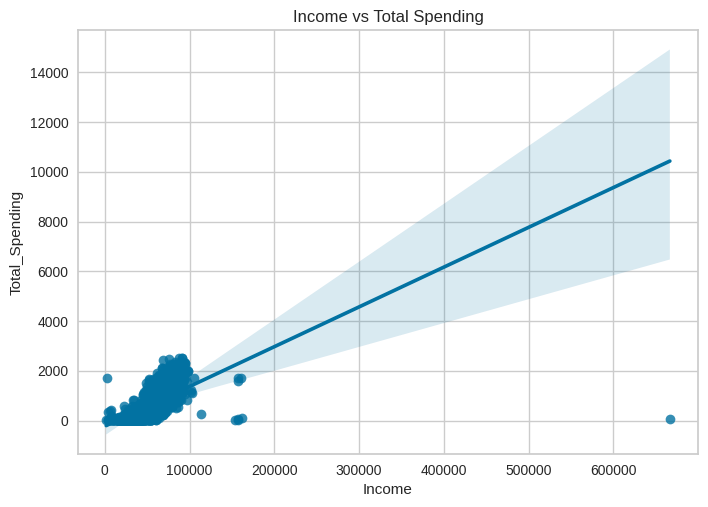

In [ ]:
#Using lineplot to examning the relationship between income vs total spending
sns.regplot(x='Income', y='Total_Spending', data=data)
plt.title("Income vs Total Spending")
plt.show()

##### **Observations: There is a linear relationship between the Income and the Total Spending**

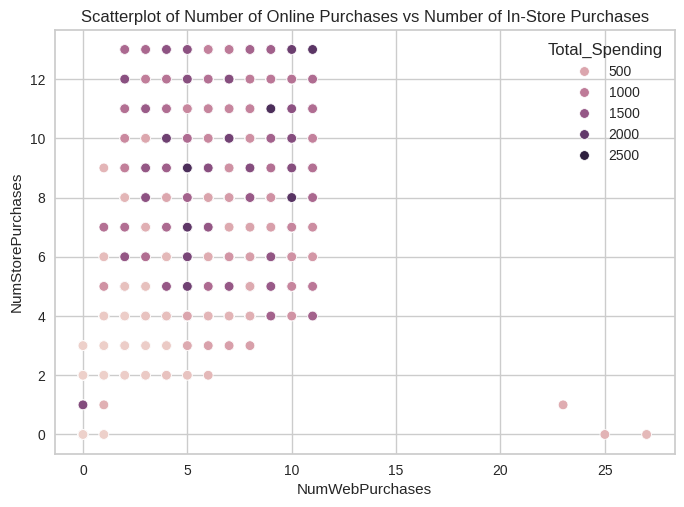

In [ ]:
#Using the scatterplot with number of online purchase and number of in store purchase to see with method giving more benefit to the company
sns.scatterplot(x='NumWebPurchases', y='NumStorePurchases', hue='Total_Spending', data=data)
plt.title("Scatterplot of Number of Online Purchases vs Number of In-Store Purchases")
plt.show()

##### **Observations: Total Spending by online purchases > Total Spending by In-Store purchases. The more purchases, the more spending. However, there still people purchase a lot with less spending, which can be people buy with a lot of discounted products**

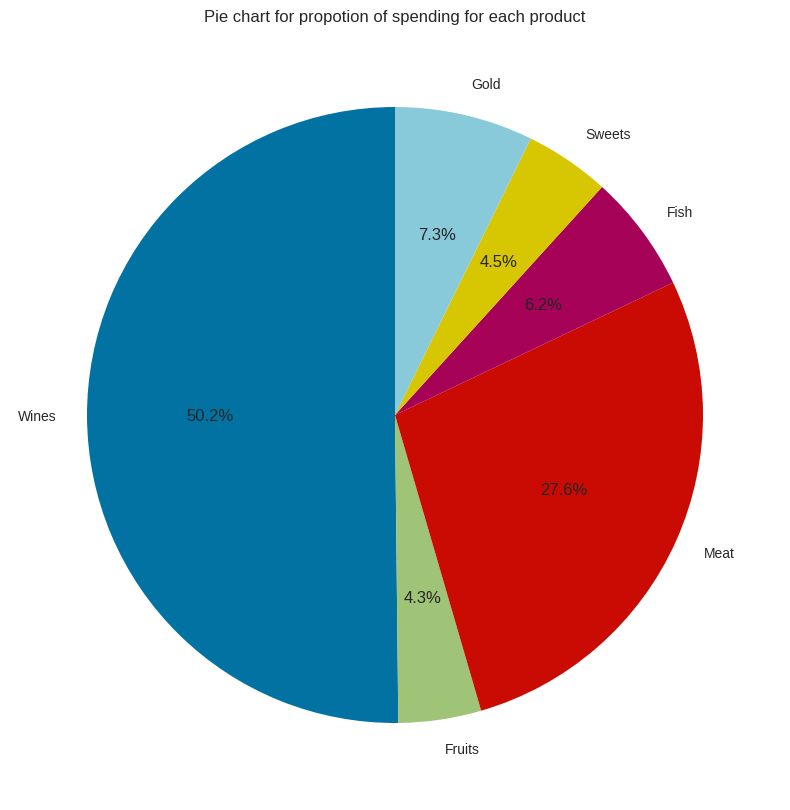

In [ ]:
# Using pie chart for knowing wich product people spent most of their money on
plt.figure(figsize=(10, 10))
plt.pie(data[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(),
        labels=['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold'],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Pie chart for propotion of spending for each product")
plt.show()

#####Observations: People spent the most of their money on the Wines

Text(0.5, 1.0, 'Distribution of Number of Visits to Website vs Number of Online Purchases')

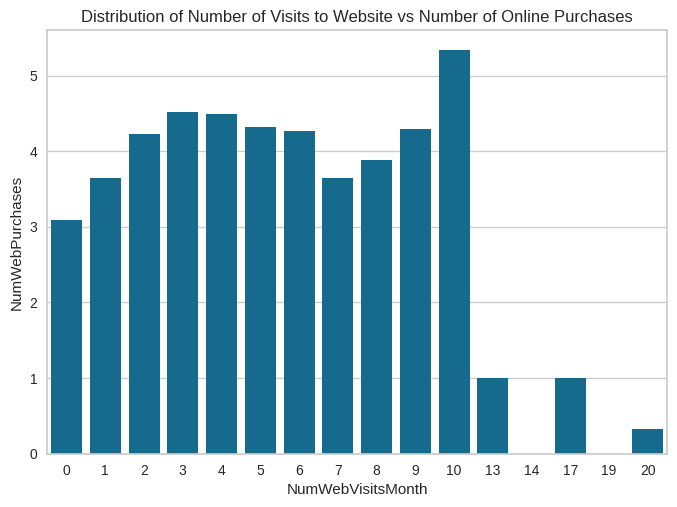

In [ ]:
# Using the barplot to see the distribution between number of visits to the company website and the number of online purchase thourgh the website
sns.barplot(x='NumWebVisitsMonth', y='NumWebPurchases', errorbar=None, data=data)
plt.title("Distribution of Number of Visits to Website vs Number of Online Purchases")

##### **Observations: The more people visit the website, the more online purchase. However, there is a number of people visit the website above 10 times with less online purhcase**

## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

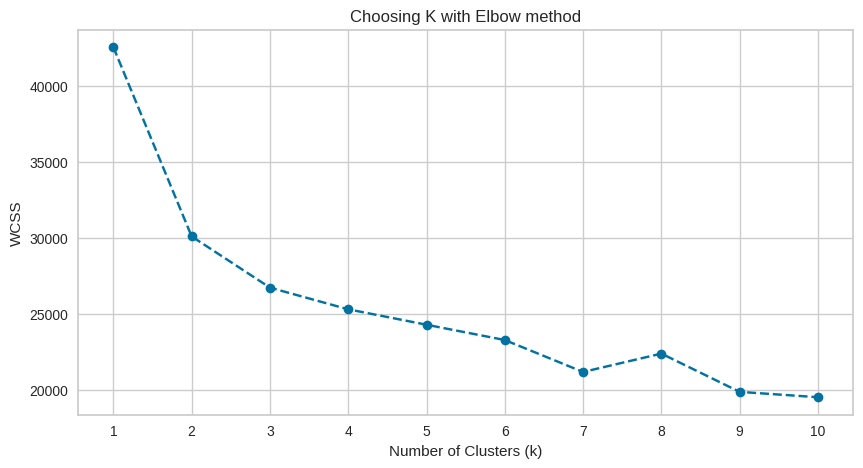

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.select_dtypes(include=['number']))
# create an empty list to store data
WCSS = []
# Define clusters
Clusters = range(1,11)
# test model with clustering number range from 1 to 10
for k in Clusters:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    WCSS.append(kmeans.inertia_)

#plotting the draft
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), WCSS, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Choosing K with Elbow method')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

##### **Observations: Looking at the plot, we can say that elbow point is achieved for k=2.**

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

Text(0, 0.5, 'Silhouette Score')

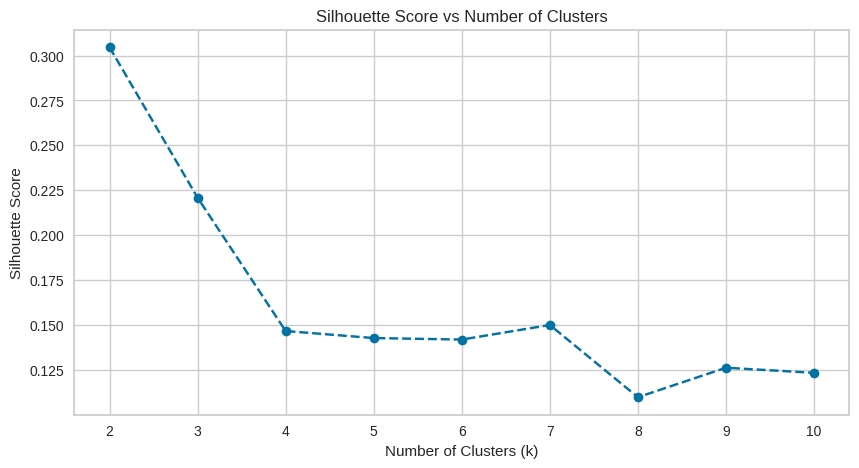

In [ ]:
# Creatig an empty dictionary for storing Silhoutte score for storing each value of k
silhoutte_scores = {}
# iterate for a range of Ks and fit the scaled data to the algorithm. Store the Silhouette score for that k
for k in Clusters[1:]:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    labels = kmeans.predict(data_scaled)
    silhoutte_scores[k] = silhouette_score(data_scaled, kmeans.labels_)
#plotting the elbow plot
plt.figure(figsize=(10, 5))
plt.plot(silhoutte_scores.keys(), silhoutte_scores.values(), marker='o', linestyle='--')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

##### **Observations: We can see that with the k=2 have the highest Silhoutte Score, which mean the answer is not different**

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
import time
#Initialize the final model with approriate number of cluster (k=2)
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42)
#Start the timer
start_time = time.time()
#fit the final model in sclaed data
kmeans.fit(data_scaled)
#End the timer and calculate the time its take for the model to fit the data
end_time = time.time()
total_time = end_time - start_time

print(f"Total time taken to fit the model: {total_time:.4f} seconds")

Total time taken to fit the model: 0.0075 seconds


In [ ]:
# Assign the cluster labels to the original DataFrame
data['Cluster'] = kmeans.labels_

##### **Observations: we can see that the total time taken to fit the model is _____**

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

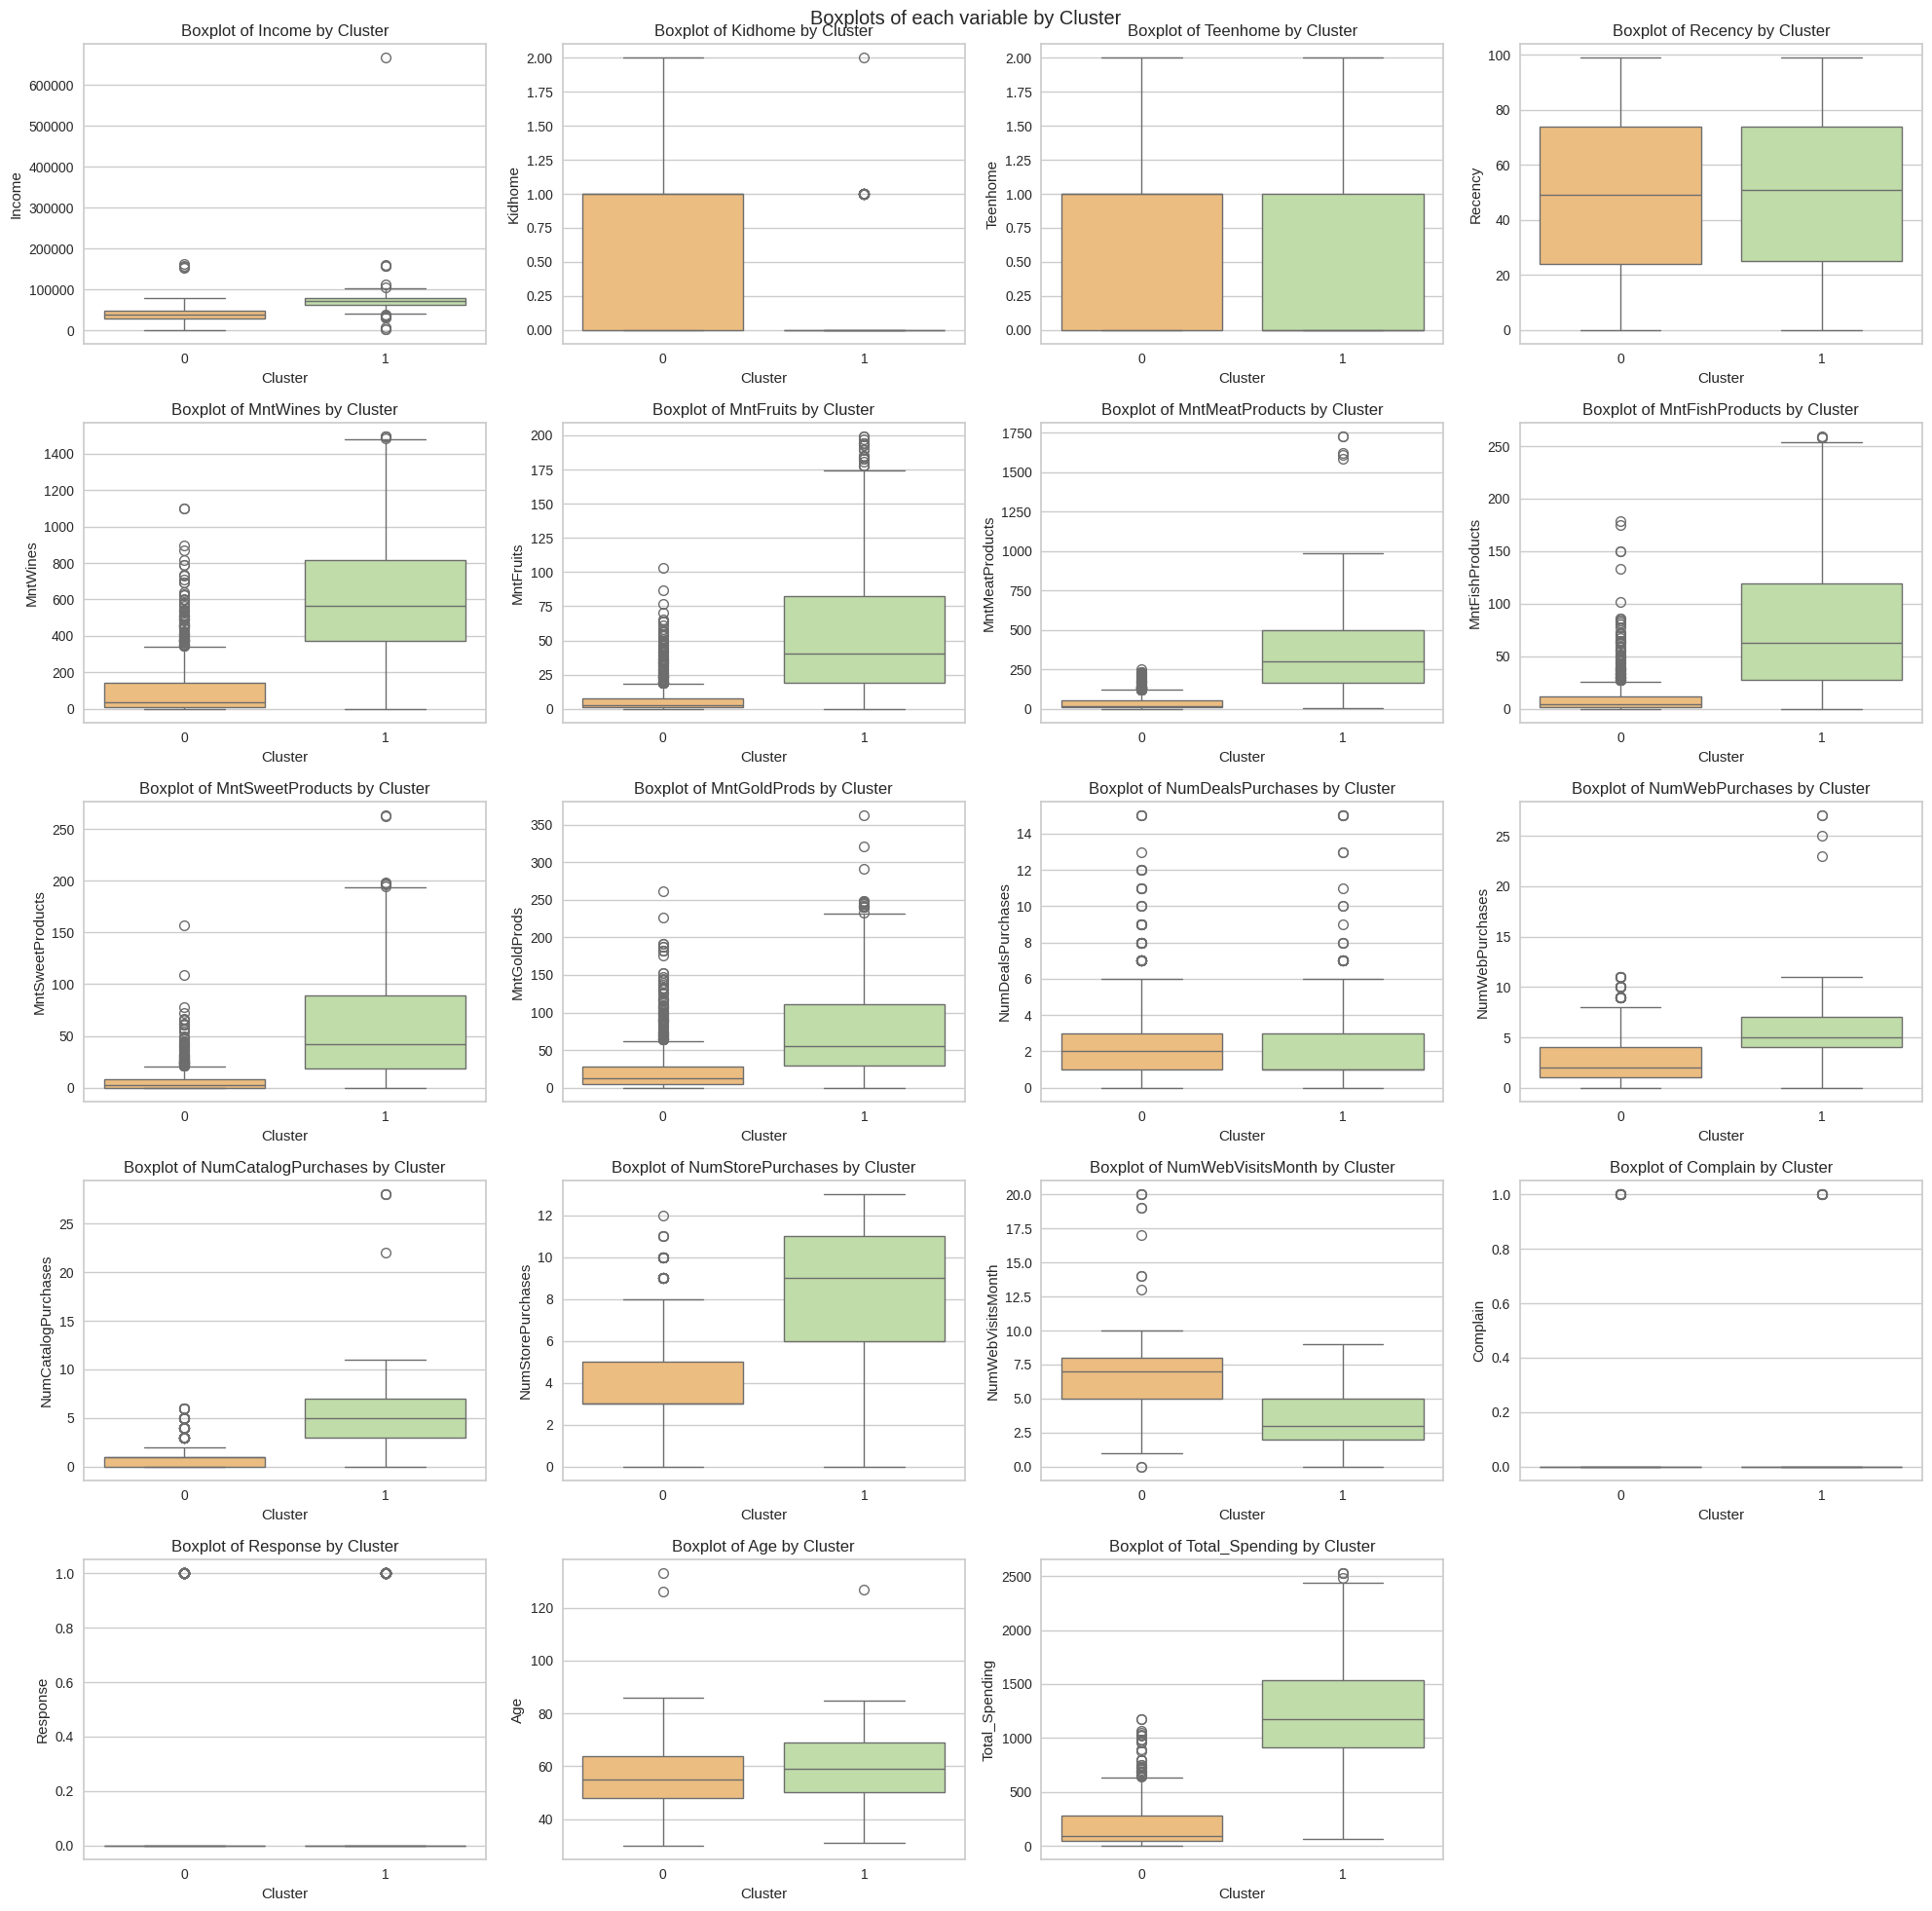

In [ ]:
plt.figure(figsize=(20,20))
plt.suptitle("Boxplots of each variable by Cluster")
for i, variable in enumerate(data.columns.to_list()[:-1]):
    plt.subplot(5, 4, i+1)
    sns.boxplot(data=data, x='Cluster', y=variable, palette='Spectral')
    plt.title(f'Boxplot of {variable} by Cluster')
plt.tight_layout()
plt.show()

##### **Observations: Based on the customer dataset, We can split the Customers into two groups**

*   High-value Customers (Cluster 1): Having higher income with less children and more spending.
*   Low-value Customers (Cluster 0): Having lower income with more children and lower spending.








#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

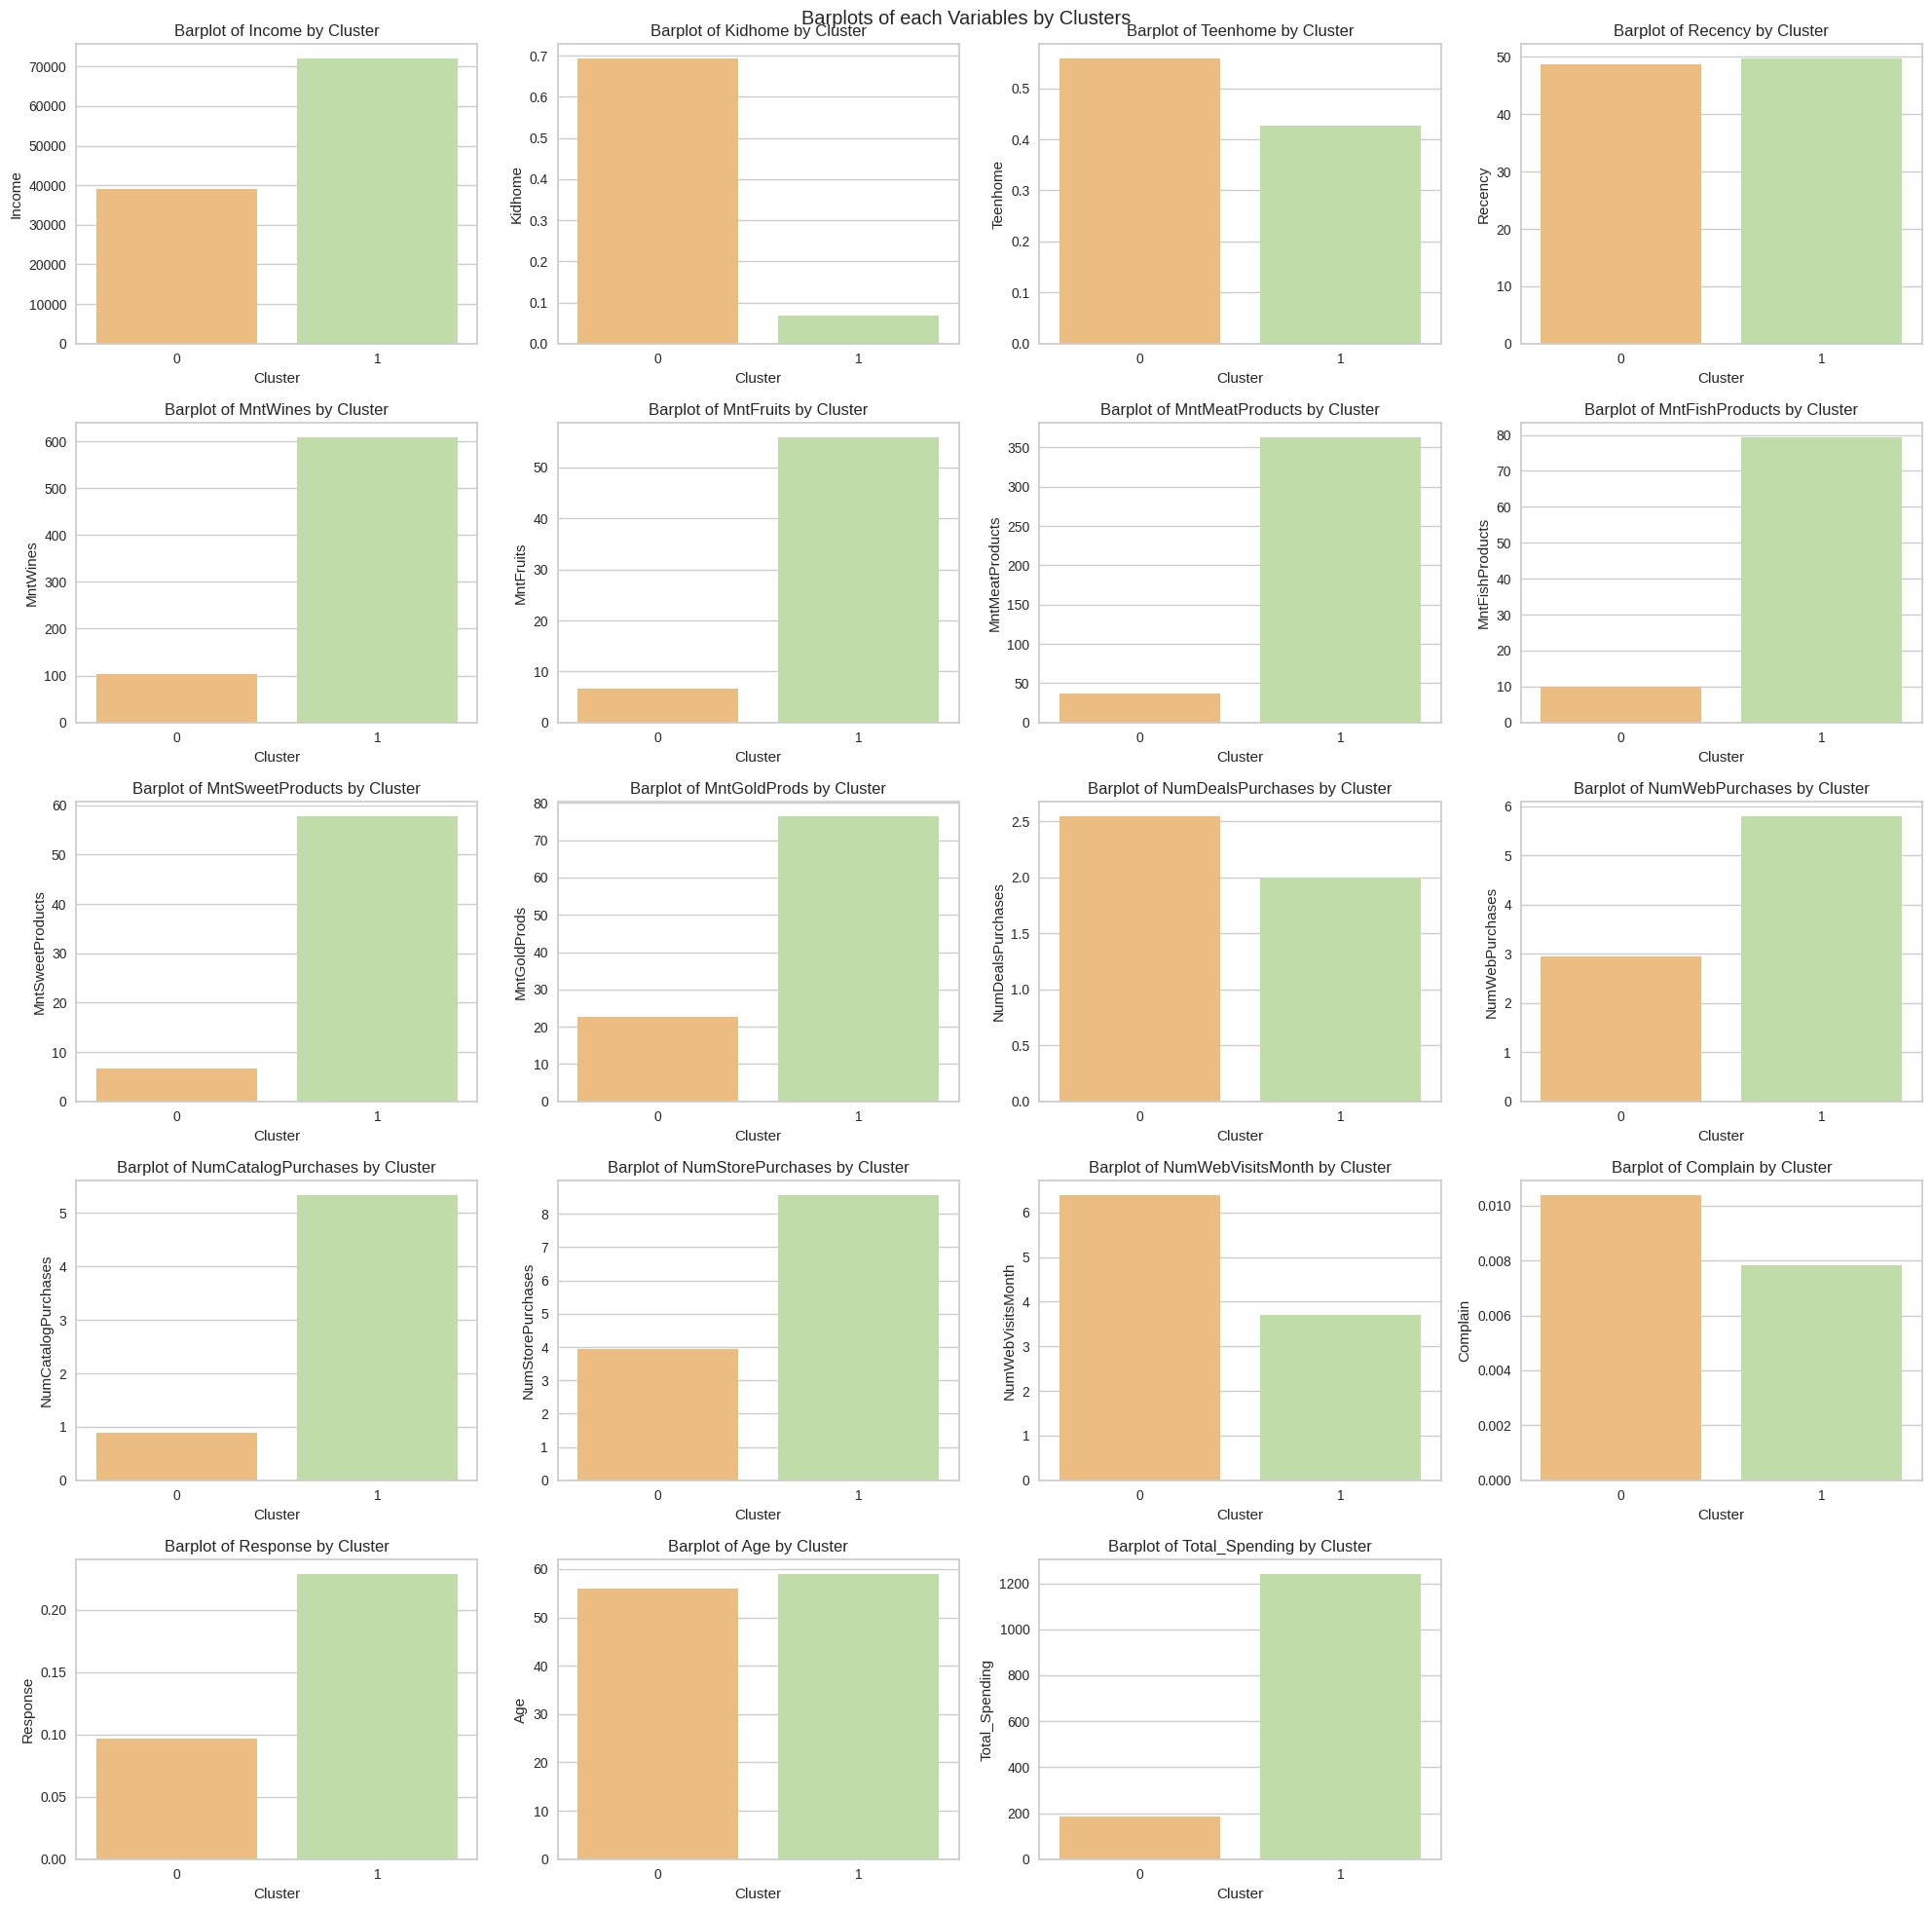

In [ ]:
plt.figure(figsize=(20,20))
plt.suptitle("Barplots of each Variables by Clusters")
for i, variable in enumerate(data.columns.to_list()[:-1]):
    plt.subplot(5, 4, i+1)
    sns.barplot(data=data, x='Cluster', y=variable, palette='Spectral', errorbar = None )
    plt.title(f'Barplot of {variable} by Cluster')
plt.tight_layout()
plt.show()

##### **Observations:**
***Based on the barplot, we can see the main difference between two groups of customers***

1.   The Income and Children VS Spending


*   High-value Customers (Cluster 1) have higher income and less children              
--> spend more money on purchasing products
*  Low-value Customers (CLuster 0) have lower Income and more children  
--> split their money on education, healthcare, etc for their children    
--> spend less money on purchasing products


2. Number of purchase using discount and number of visits to the companies's website


*   High-value Customers (Cluster 1) have lower rate      
--> Not much Intention about finding deals
*  Low-value Customers (Cluster 0) have higher rate           
--> Tend to find deals through checking website

***However, There are some similarities in two groups of customers***


1.   Spend most of money on Luxury Products (Wines and Meat)
2.   In-store purchases > Online Purchases








## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

### **Business Recommendations based on Cluster Analysis:**

Based on the insights derived from the K-Means clustering, customers can be broadly categorized into two main segments: High-Value Customers (Cluster 1) and Low-Value Customers (Cluster 0). Here are targeted recommendations for each:

#### **1. High-Value Customers (Cluster 1):**
   - **Characteristics:** Higher income, fewer children, higher overall spending, less driven by discounts.
   - **Recommendations:**
     - **Personalized Premium Offers:** Develop exclusive loyalty programs, early access to new premium products (especially wines and meats), and personalized recommendations based on their past high-value purchases.
     - **Luxury Experiences:** Offer special events, wine tasting sessions, or VIP shopping experiences to enhance their sense of exclusivity and foster loyalty.
     - **Convenience and Service:** Emphasize seamless shopping experiences, fast delivery, and premium customer service, as these customers value efficiency over discounts.
     - **Avoid Discount Overload:** While occasional targeted promotions might be acceptable, do not heavily rely on discounts for this segment, as it might devalue the brand perception.

#### **2. Low-Value Customers (Cluster 0):**
   - **Characteristics:** Lower income, more children, lower overall spending, highly influenced by discounts and promotions, actively visit the website for deals.
   - **Recommendations:**
     - **Value-Oriented Marketing:** Focus on promotional offers, bundled deals, and discounts to attract and retain these customers. Highlight the cost-saving benefits.
     - **Family-Centric Products:** Promote products suitable for families or budget-conscious purchases, considering their higher number of children.
     - **Digital Engagement:** Strengthen the online presence and website experience, as these customers frequently visit the website for deals. Implement targeted online ads and email campaigns showcasing promotions.
     - **Loyalty Programs with Accumulative Rewards:** Introduce loyalty programs that offer points or small discounts that accumulate over time, encouraging repeat purchases rather than large upfront spending.

#### **3. General Product & Channel Strategies (Applicable to both segments):**
   - **Product Focus:** prioritize the promotion of **Wines and Meat Products**.
   - **Hybrid Channel Approach:** Despite the prevalence of online activity for discount-seeking customers, in-store purchases still dominate for both groups. This suggests:
     - **Enhance In-Store Experience:** Maintain a pleasant and efficient in-store shopping environment, perhaps by offering in-store exclusive promotions or personalized assistance.
     - **Integrate Online and Offline:** Ensure a seamless transition between online browsing and in-store purchasing (e.g., click-and-collect, in-store pickup for online orders) to cater to varied preferences.